<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C9_Ejercicios_del_Libro_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio para la Sección 1**

**Objetivo**: Comprender la diferencia entre árboles de clasificación y regresión.

**Instrucciones**:

    1. Cargar el dataset de precios de viviendas (sns.load_dataset("house_prices")).
    2. Entrenar un árbol de clasificación para predecir si una casa es "barata" o "cara".
    3. Entrenar un árbol de regresión para predecir el precio exacto de la casa.
    4. Comparar ambos enfoques y explicar sus diferencias.


# **1. Cargar el dataset de precios de viviendas (sns.load_dataset("house_prices")).**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar dataset de viviendas

data = fetch_california_housing(as_frame=True)
df = data.frame
display(df.head())
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# **2. Entrenar un árbol de clasificación para predecir si una casa es "barata" o "cara".**


In [ ]:
# Creamos variable 'Categoria_Precio'
median_price = df['MedHouseVal'].median()
print("Usamos Mediana (Precio): ", median_price)

df['Categoria_Precio'] = df['MedHouseVal'].apply(lambda x: 'Cara' if x > median_price else 'Barata')
df["Categoria_Precio"].value_counts()

Usamos Mediana (Precio):  1.797


,count
Categoria_Precio,
Barata,10323
Cara,10317


In [ ]:
# Variables predidctora
X_class = df.drop(columns=["Categoria_Precio", "MedHouseVal"])
y_class = df["Categoria_Precio"]

# Dividir los datos 80% entrenamiento y 20% para realizar pruebas
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.30, random_state=42
)

# Modelo
classT = DecisionTreeClassifier(max_depth=4, random_state=42)
classT.fit(X_train, y_train)

# Predicción de nuevos valores
y_pred = classT.predict(X_test)

# Medidas para evaluar el árbol de clasificación
accuracy = accuracy_score(y_test, y_pred)
print("\nPrecisión del árbol de clasificación: ", accuracy)
print("\nReporte de Clasificación:\n",classification_report(y_test, y_pred))
print("\nMatriz:\n",confusion_matrix(y_test, y_pred))



Precisión del árbol de clasificación:  0.7822997416020672

Reporte de Clasificación:
               precision    recall  f1-score   support

      Barata       0.74      0.86      0.80      3069
        Cara       0.84      0.70      0.76      3123

    accuracy                           0.78      6192
   macro avg       0.79      0.78      0.78      6192
weighted avg       0.79      0.78      0.78      6192


Matriz:
 [[2653  416]
 [ 932 2191]]


# **3. Entrenar un árbol de regresión para predecir el precio exacto de la casa.**


In [ ]:
# Elimina 'Categoria_Precio' y 'MedHouseVal' praa regresión
X_reg = df.drop(columns=["Categoria_Precio", "MedHouseVal"])
y_reg = df["MedHouseVal"]

# Dividir los datos 80% entrenamiento y 20% para realizar pruebas
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

# Modelo
reg = DecisionTreeRegressor(max_depth=4, random_state=42)
reg.fit(X_train, y_train)

# Predicción de nuevos valores
y_pred_reg = reg.predict(X_test)

# Evaluación del modelo de regresión (MAE/MSE/RMSE/R2)
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)
rmse = np.sqrt(mse)
print("\nMAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.5572704960046666
MSE: 0.567419678079617
RMSE: 0.7532726452484632
R2: 0.5676934558406004


### Visualización del Árbol de Clasificación

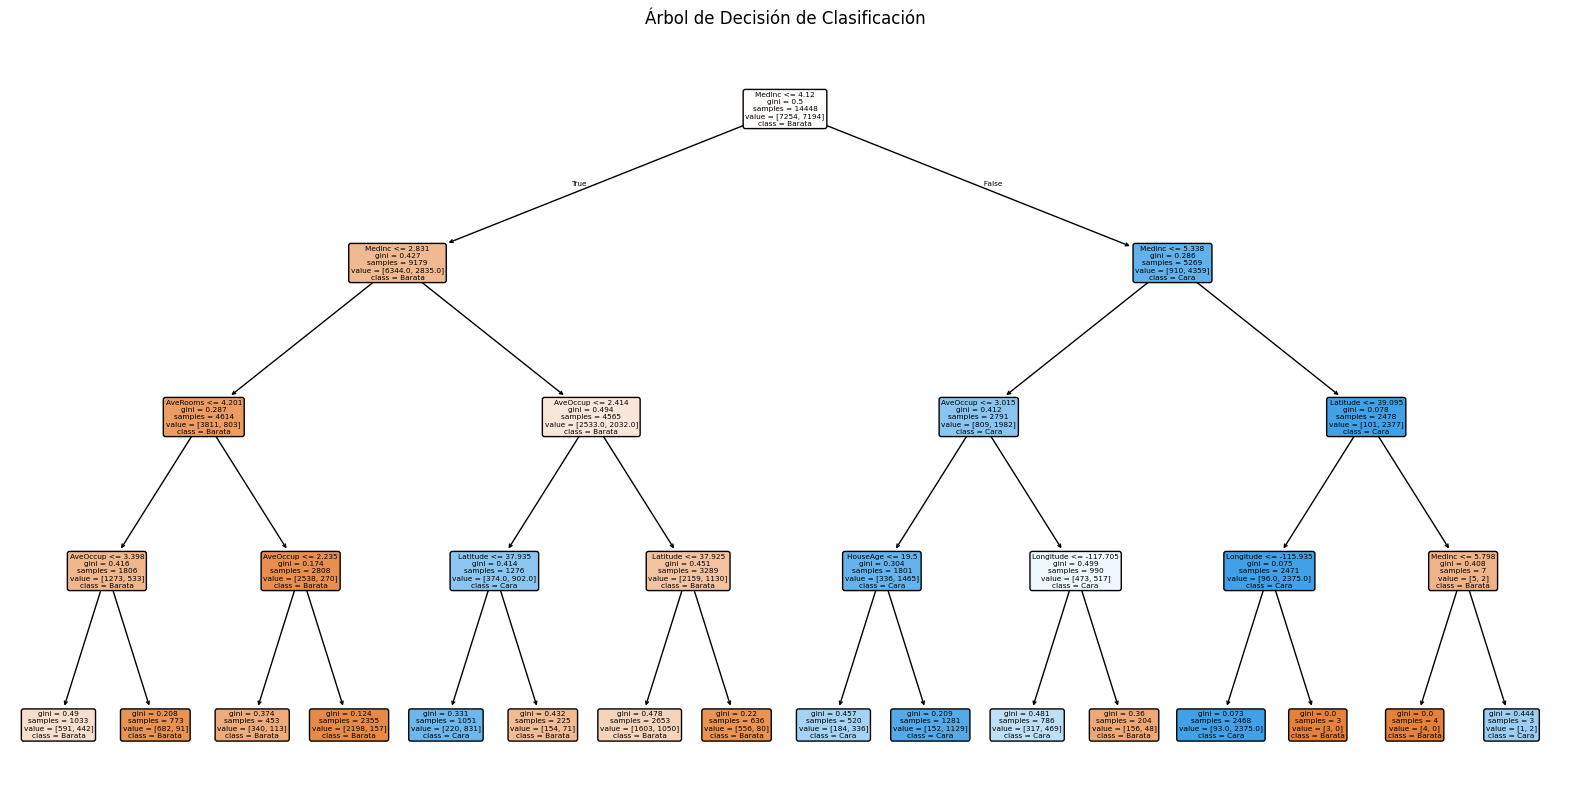

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(classT, feature_names=X_class.columns.tolist(), class_names=classT.classes_.tolist(), filled=True, rounded=True)
plt.title('Árbol de Decisión de Clasificación')
plt.show()

### Visualización del Árbol de Regresión

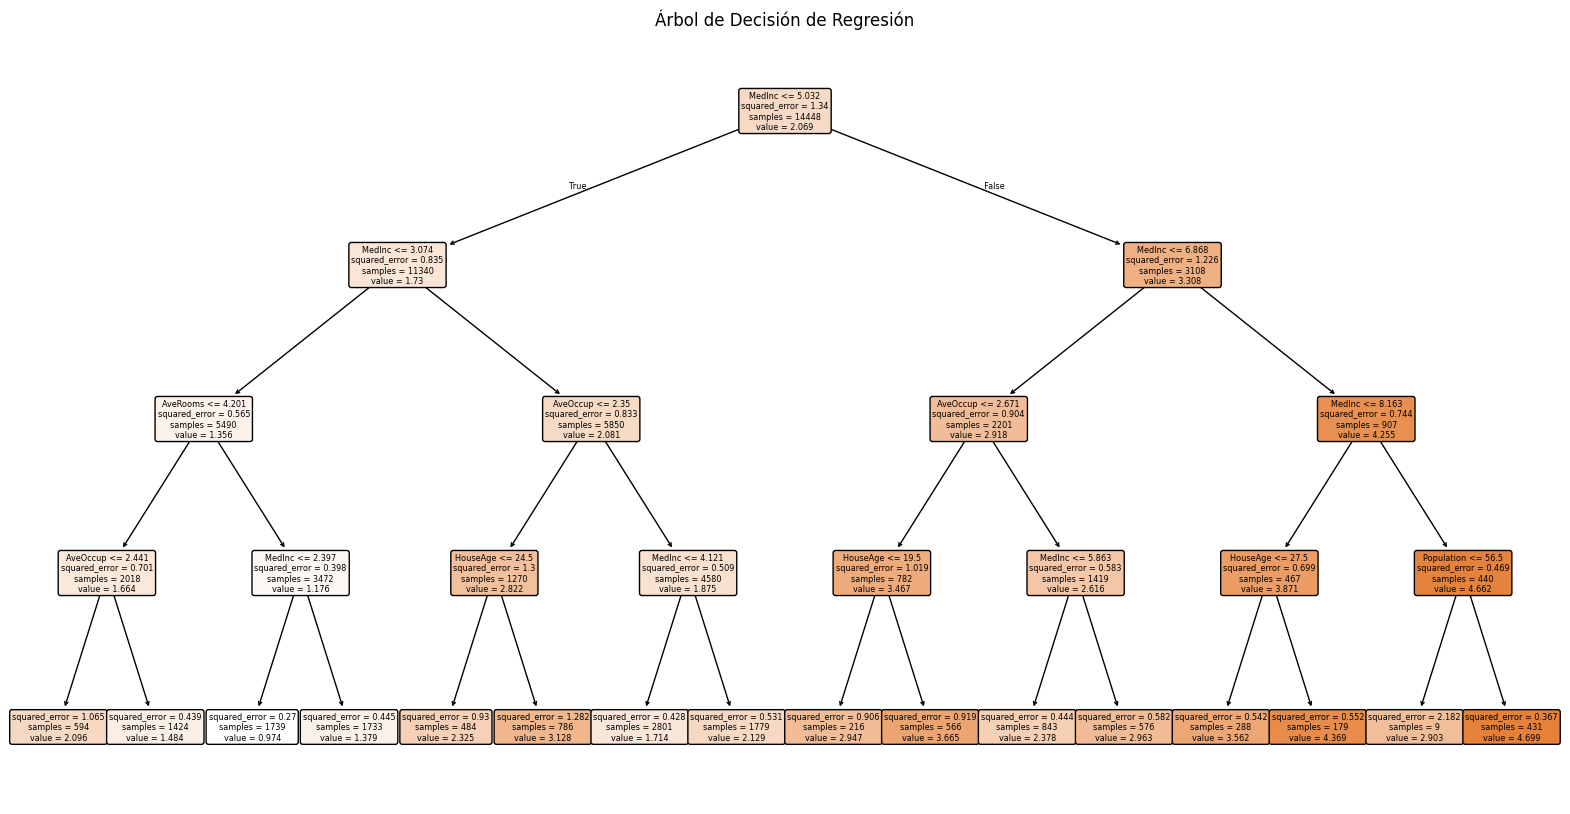

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(reg, feature_names=X_reg.columns.tolist(), filled=True, rounded=True)
plt.title('Árbol de Decisión de Regresión')
plt.show()

# Visualización Precio Real y Precio de Predicción

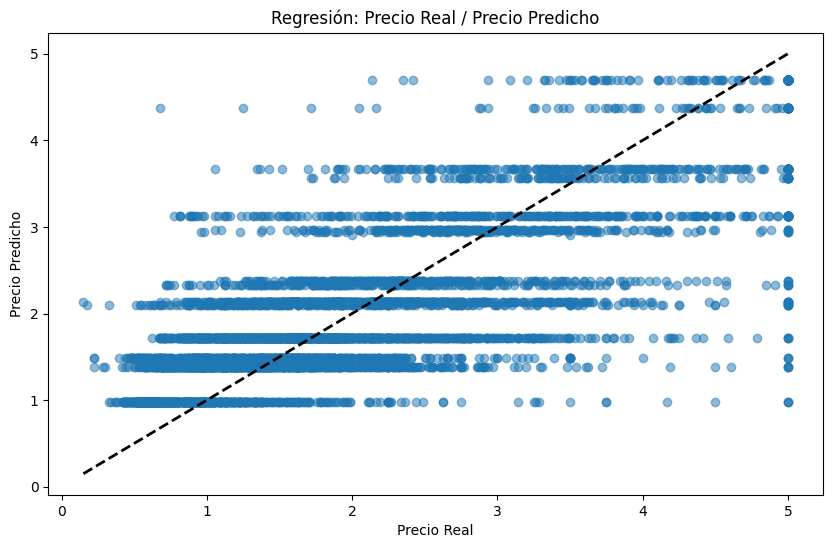

In [ ]:
# comparación entre el valor real y el valor predicho
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_reg, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Regresión: Precio Real / Precio Predicho')
plt.show()


# **4. Comparar ambos enfoques y explicar sus diferencias.**

Los árboles de clasificación y regresión son modelos que dividen los datos en subconjuntos para realizar predicciones, se diferencian por el tipo de variable objetivo.

El árbol de clasificación trabaja con variables categóricas y predice una clase, como determinar si una casa es "Barata" o "Cara", utilizando criterios como Gini o entropía para crear las divisiones.

En cambio, el árbol de regresión utiliza variables numéricas continuas y estima valores exactos, como el precio de una vivienda, minimizando la varianza o el error cuadrático medio (MSE).

Mientras el primero indica a qué categoría pertenece un caso, el segundo predice el valor que tendrá.

**Preguntas de Reflexión:**

    1. ¿Cuándo es más útil un árbol de clasificación en lugar de uno de regresión?
    2. ¿Cómo afecta la profundidad del árbol a la precisión del modelo?
    3. ¿Cómo podríamos mejorar la predicción con más atributos?


## Respuestas a las Preguntas de Reflexión

1.  **¿Cuándo es más útil un árbol de clasificación en lugar de uno de regresión?**

Un árbol de clasificación es más útil cuando la variable que queremos predecir es **categórica**, es decir, cuando queremos predecir a qué grupo o clase pertenece una observación. Ejemplos incluyen predecir si un cliente comprará un producto (sí/no), si un correo es spam/no-spam, o en nuestro caso, si una casa es 'barata' o 'cara'. Su objetivo es clasificar elementos en categorías predefinidas.

2.  **¿Cómo afecta la profundidad del árbol a la precisión del modelo?**

La profundidad del árbol determina cuantos niveles de decisiones puede tener el árbol. Podemos controlar la profundidad con el parámetro max_depth.

Si el árbol generado es poco profundo, puede ser simple, no reflejar la complejidad de los datos, baja precisión y resultar en un **subajuste (underfitting)**.

Si el árbol es muy profundo, los datos de entrenamiento pueden aprender con excesivo detalle, ruido, lo que lleva a un **sobreajuste (overfitting)**. La precisión en el conjunto de entrenamiento será alta, pero en el conjunto de prueba será baja.

El objetivo es encontrar una profundidad óptima que equilibre el subajuste y el sobreajuste para lograr una buena generalización en datos nuevos.

3.  **¿Cómo podríamos mejorar la predicción con más atributos?**

Agregar mas características relevantes puede mejorar significativamente la predicción si estos atributos proporcionan información adicional sobre la variable objetivo. Un atributo nuevo podría revelar patrones que no eran visibles con los atributos existentes.Puede ayudar al modelo a tomar decisiones más informadas, reduciendo el sesgo. Atributos irrelevantes o redundantes pueden introducir ruido o complejidad innecesaria, lo que puede llevar al sobreajuste o a un mayor tiempo de entrenamiento.

# **Ejercicio para la Sección 2**

**Objetivo**: Comparar ID3 y CART en un dataset real.

**Instrucciones**:

    1. Cargar el dataset sns.load_dataset("penguins").
    2. Aplicar un árbol ID3 (criterion="entropy") para predecir la especie del pingüino.
    3. Aplicar un árbol CART (criterion="gini") con los mismos datos.
    4. Comparar las precisiones de ambos modelos.


# **Comparar ID3 y CART.**


In [ ]:
# 1. Cargar el dataset sns.load_dataset("penguins").
# Carga de librerías
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cargar dataset de pingüinos y  exploración inicial
df = sns.load_dataset("penguins").dropna()
display(df.head())
df.describe()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
# Preprocesamiento
df["sex"] = df["sex"].map({"male": 1, "female": 0})

# selección de variables predictoras y variable objetivo
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

df["species"].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


In [ ]:
# Dividir en entrenamiento (80%)  y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (266, 4)
Prueba: (67, 4)


In [ ]:
# 2. Aplicar un árbol ID3 (criterion="entropy") para predecir la especie del pingüino.
tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
tree_id3.fit(X_train, y_train)
y_pred_id3 = tree_id3.predict(X_test)

# 3. Aplicar un árbol CART (criterion="gini") con los mismos datos.
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
tree_cart.fit(X_train, y_train)
y_pred_cart = tree_cart.predict(X_test)


# Visualización de cada árbol

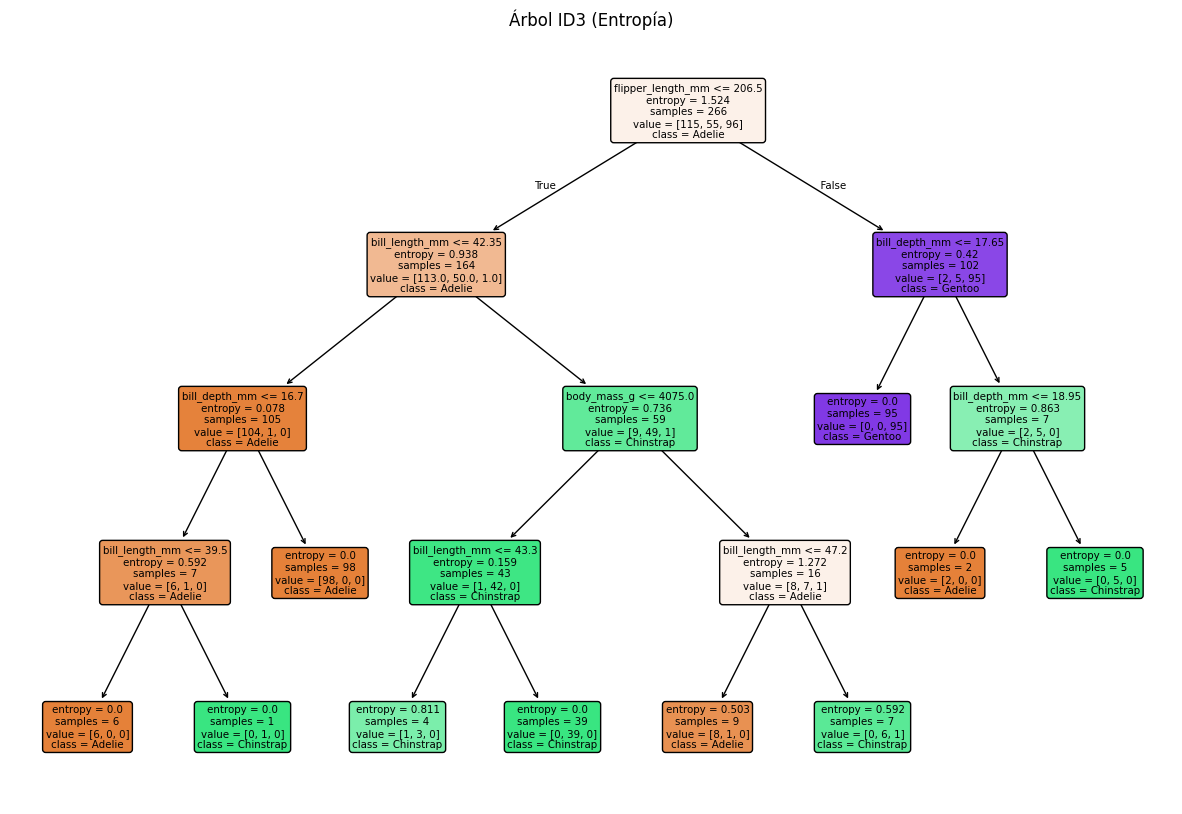

In [ ]:
# Visualización -  Árbol ID3
plt.figure(figsize=(15, 10))
plot_tree(tree_id3, feature_names=X.columns,
    class_names=tree_id3.classes_, filled=True, rounded=True
)
plt.title("Árbol ID3 (Entropía)")
plt.show()

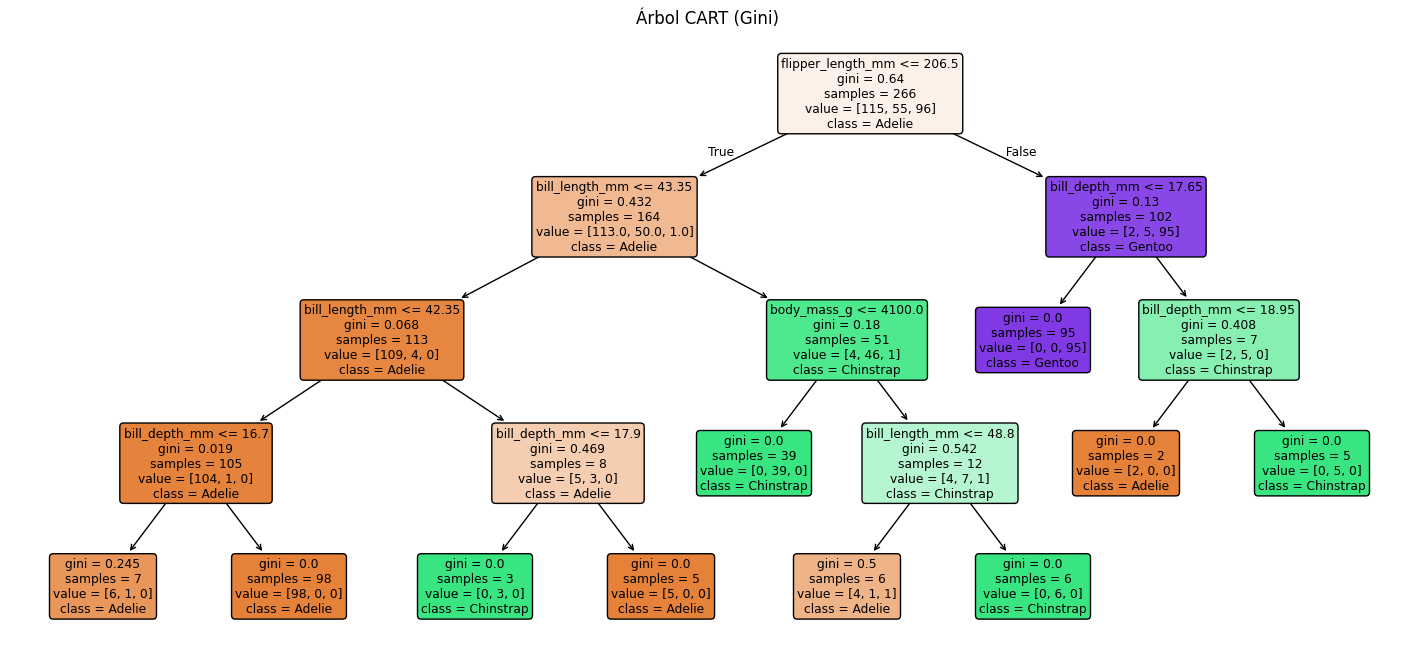

In [ ]:
# Visualización -  Árbol CART
plt.figure(figsize=(18, 8))
plot_tree(tree_cart,feature_names=X.columns,
    class_names=tree_cart.classes_, filled=True, rounded=True
)
plt.title("Árbol CART (Gini)")
plt.show()

# Evaluación de ambos modelos.

In [ ]:
# 4. Comparar las precisiones de ambos modelos.
# Evaluación de precisión
print("Precisión ID3 (Entropía):", accuracy_score(y_test, y_pred_id3))
print("Precisión CART (Gini):", accuracy_score(y_test, y_pred_cart))

Precisión ID3 (Entropía): 0.9850746268656716
Precisión CART (Gini): 0.9850746268656716


In [ ]:
print("\nReporte de Clasificación para CART:")
print(classification_report(y_test, y_pred_cart))

print("\nReporte de Clasificación para ID3:")
print(classification_report(y_test, y_pred_id3))


Reporte de Clasificación para CART:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67


Reporte de Clasificación para ID3:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



### Matrices de Confusión (ID3 y CART)

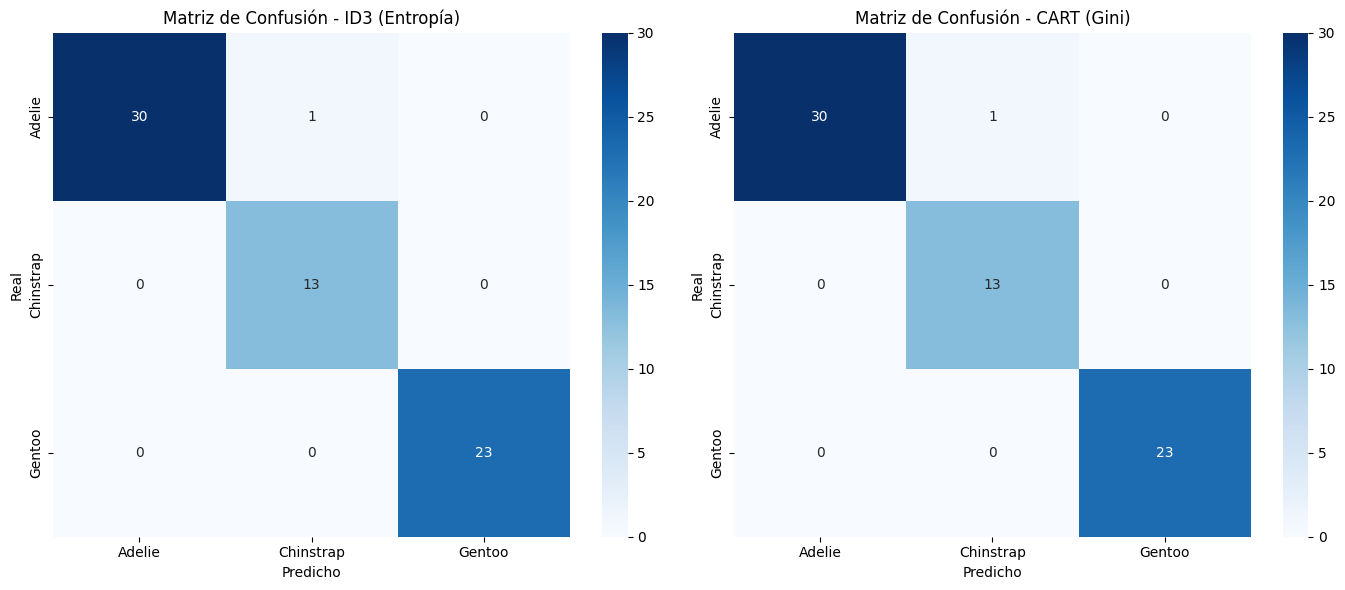

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular matrices de confusión
cm_id3 = confusion_matrix(y_test, y_pred_id3)
cm_cart = confusion_matrix(y_test, y_pred_cart)

# Obtener los nombres de las clases (especies de pingüinos)
class_names = tree_id3.classes_

plt.figure(figsize=(14, 6))

# Heatmap para ID3
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.heatmap(cm_id3, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - ID3 (Entropía)')
plt.xlabel('Predicho')
plt.ylabel('Real')

# Heatmap para CART
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.heatmap(cm_cart, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - CART (Gini)')
plt.xlabel('Predicho')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

**Preguntas de Reflexión:**

1. ¿Qué algoritmo fue más preciso en este dataset?
2. ¿Cómo influye la profundidad máxima del árbol en la precisión?
3. ¿Cómo podríamos mejorar estos modelos?


## Respuestas a las Preguntas de Reflexión:

1.  **¿Qué algoritmo fue más preciso en este dataset?**
    *   Según los resultados mostrados:
        *   `Precisión ID3 (Entropía): 0.0.9850746268656716`
        *   `Precisión CART (Gini): 0.9850746268656716`
    *   Ambos algoritmos, ID3 (usando entropía) y CART (usando Gini), obtuvieron la misma precisión en este dataset con la configuración de `max_depth=4` y `random_state=42`. Por lo tanto, fueron igualmente precisos en este caso específico.

2.  **¿Cómo influye la profundidad máxima del árbol en la precisión?**
    *   La profundidad máxima (`max_depth`) es un hiperparámetro crucial. Una profundidad insuficiente (`max_depth` pequeña) puede llevar a un **subajuste (underfitting)**, donde el modelo es demasiado simple y no captura bien los patrones en los datos, resultando en baja precisión. Por otro lado, una profundidad excesiva (`max_depth` grande) puede causar **sobreajuste (overfitting)**, donde el modelo memoriza el ruido de los datos de entrenamiento y no generaliza bien a datos nuevos, lo que también reduce la precisión en el conjunto de prueba. Encontrar la `max_depth` óptima es clave para equilibrar el sesgo y la varianza y lograr la mejor precisión posible.

3.  **¿Cómo podríamos mejorar estos modelos?**
    *   Existen varias estrategias para mejorar el rendimiento de los árboles de decisión:
        *   **Ajuste de hiperparámetros**: Utilizar técnicas como `GridSearchCV` o `RandomizedSearchCV` para encontrar la combinación óptima de hiperparámetros (`max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`, etc.).
        *   **Ingeniería de características**: Crear nuevas características a partir de las existentes o seleccionar las más relevantes para el problema.
        *   **Eliminación de ruido y valores atípicos**: Limpiar el dataset de datos erróneos o extremos que puedan distorsionar el aprendizaje del árbol.
        *   **Ensamblaje de modelos (Ensemble Methods)**: Combinar múltiples árboles de decisión para formar un modelo más robusto. Ejemplos incluyen `RandomForestClassifier`, `GradientBoostingClassifier` o `AdaBoostClassifier`.
        *   **Pruning (Poda)**: Reducir el tamaño del árbol para evitar el sobreajuste. Esto se puede hacer de forma pre-poda (limitando el crecimiento del árbol durante la construcción) o post-poda (construyendo un árbol completo y luego eliminando ramas).
        *   **Mayor cantidad de datos**: Si es posible, utilizar más datos de entrenamiento, ya que esto a menudo ayuda a los modelos a aprender patrones más generales y robustos.

# **Actividad para la Sección 3**

**Objetivo**: Optimizar un Árbol de Decisión para mejorar su desempeño.

**Instrucciones**:

    1. Cargar el dataset de "diabetes" (sns.load_dataset("diabetes")).
    2. Entrenar un árbol de decisión estándar y medir su precisión.
    3. Optimizar max_depth y min_samples_split usando GridSearchCV.
    4. Comparar el desempeño del modelo original vs. el optimizado.


In [35]:
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt # Import matplotlib for plot_tree and figures
from sklearn.tree import plot_tree # Import plot_tree

# 1. Cargar el dataset de "diabetes" (sns.load_dataset("diabetes")).

# Cargar dataset de diabetes desde sklearn
diabetes = load_diabetes(as_frame=True)

df = diabetes.frame.copy()
df = df.rename(columns={"target": "valor_obj"})
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,valor_obj
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [36]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,valor_obj
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [38]:
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt # Import matplotlib for plot_tree and figures
from sklearn.tree import plot_tree # Import plot_tree

# 1. Cargar el dataset de "diabetes" (sns.load_dataset("diabetes")).

# Cargar dataset de diabetes desde sklearn
diabetes = load_diabetes(as_frame=True)

df = diabetes.frame.copy()
df = df.rename(columns={"target": "valor_obj"})
df.head()
# Crear una variable objetivo binaria 'resultado' para clasificación
median_progression = df['valor_obj'].median()
df['resultado'] = (df['valor_obj'] > median_progression).astype(int) # 0 for <= median, 1 for > median
print("Usamos Mediana: ", median_progression)
display(df.head())
df["resultado"].value_counts()

Usamos Mediana:  140.5


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,valor_obj,resultado
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,0


,count
resultado,
1,221
0,221


In [40]:
# 2. Entrenar un árbol de decisión estándar y medir su precisión.
# Seleccionar variables (excluir 'resultado' y 'valor_obj' de las características)
X = df.drop(columns=["resultado", "valor_obj"])
y = df["resultado"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

# Entrenar árbol básico
original_tree_basico = DecisionTreeClassifier(random_state=42) # Renamed to avoid reinitialization issue
original_tree_basico.fit(X_train, y_train)

y_pred_tb = original_tree_basico.predict(X_test)

print("Precisión Árbol Básico:", accuracy_score(y_test, original_tree_basico.predict(X_test)))
print("\nReporte de Clasificación:\n",classification_report(y_test, y_pred_tb))
print("\nMatriz:\n",confusion_matrix(y_test, y_pred_tb))

Entrenamiento: (353, 10)
Prueba: (89, 10)
Precisión Árbol Básico: 0.651685393258427

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.69      0.56      0.62        45
           1       0.62      0.75      0.68        44

    accuracy                           0.65        89
   macro avg       0.66      0.65      0.65        89
weighted avg       0.66      0.65      0.65        89


Matriz:
 [[25 20]
 [11 33]]


In [41]:
# 3. Optimizar max_depth y min_samples_split usando GridSearchCV.
# Definir el grid de parámetros para GridSearchCV
param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

# Optimizar con GridSearchCV
# Use a new instance or the original one if it's not being modified by GridSearchCV in place
grid_tree_estimator = DecisionTreeClassifier(random_state=42) # Create a fresh instance for GridSearchCV
grid_search = GridSearchCV(grid_tree_estimator, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 3, 'min_samples_split': 2}


In [42]:
# Evaluar modelo optimizado
best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)

print("Precisión Árbol Optimizado:", accuracy_score(y_test, y_pred_best))
print("\nReporte de Clasificación:\n",classification_report(y_test, y_pred_best))
print("\nMatriz:\n",confusion_matrix(y_test, y_pred_best))


Precisión Árbol Optimizado: 0.6966292134831461

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.71      0.67      0.69        45
           1       0.68      0.73      0.70        44

    accuracy                           0.70        89
   macro avg       0.70      0.70      0.70        89
weighted avg       0.70      0.70      0.70        89


Matriz:
 [[30 15]
 [12 32]]


In [43]:
# 4. Comparación de métricas de árbol básico y árbol optimizado
# Compara accuracy
print("\nComparación de Precisión:")
print("Árbol Básico:", accuracy_score(y_test, original_tree_basico.predict(X_test))) # Use the original fitted tree
print("Árbol Optimizado:", accuracy_score(y_test, y_pred_best))


Comparación de Precisión:
Árbol Básico: 0.651685393258427
Árbol Optimizado: 0.6966292134831461


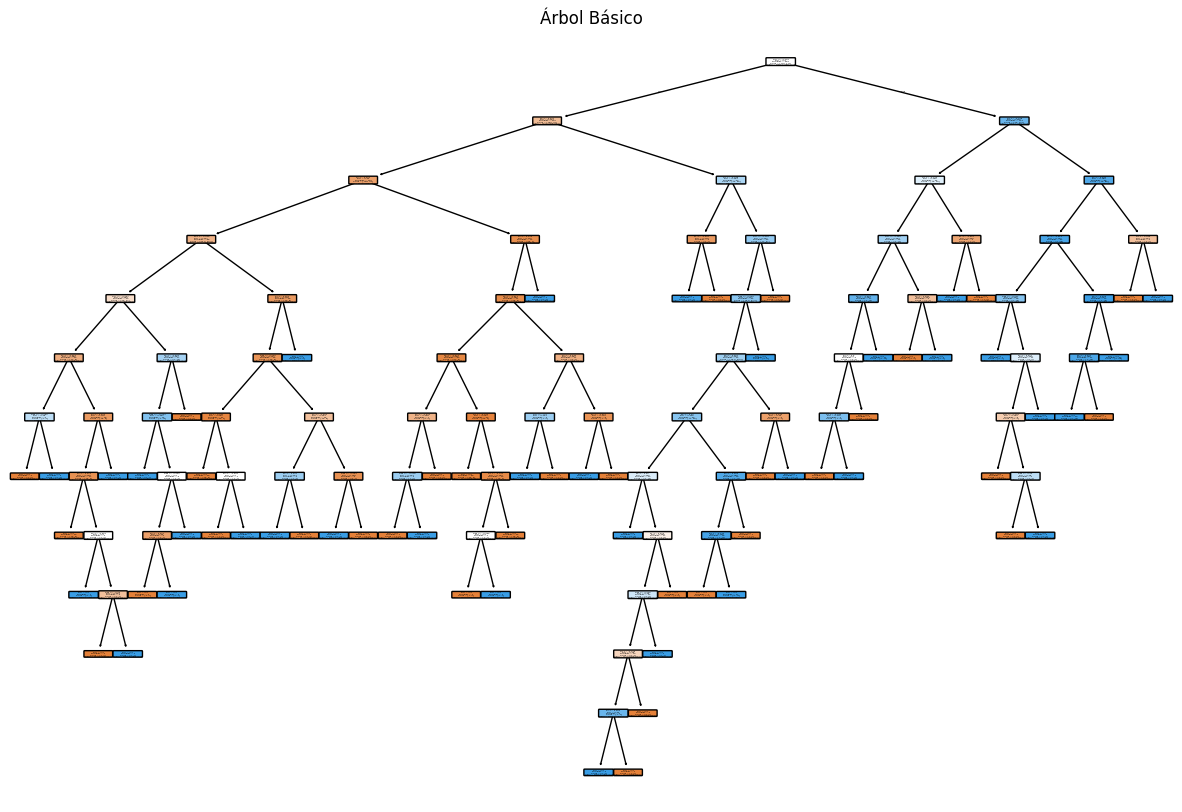

In [45]:
# Define string class names for plotting
class_names_str = ['Less Progression', 'More Progression']

# Visualización de Árbol Básico
plt.figure(figsize=(15, 10))
plot_tree(original_tree_basico, feature_names=X.columns,
    class_names=class_names_str, filled=True, rounded=True
)
plt.title("Árbol Básico")
plt.show()

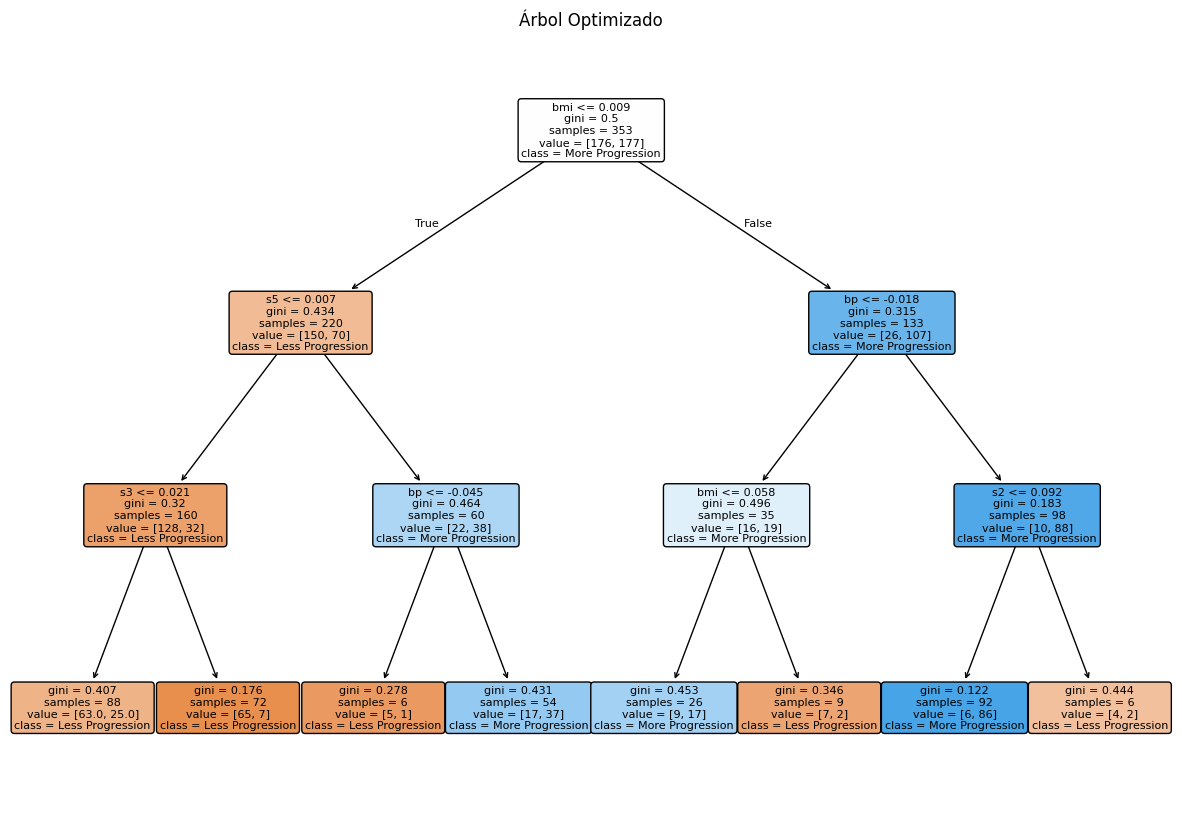

In [46]:
# Visualización Árbol Optimizado
plt.figure(figsize=(15, 10))
plot_tree(best_tree, feature_names=X.columns,
    class_names=class_names_str, filled=True, rounded=True
)
plt.title("Árbol Optimizado")
plt.show()

**Preguntas de Reflexión:**

    1. ¿Cómo cambió la precisión después de la optimización?
    2. ¿Qué parámetros fueron más importantes en la mejora del modelo?
    3. ¿Cómo afecta la poda al rendimiento del árbol?


## Respuestas a las Preguntas de Reflexión (Sección 3):

1.  **¿Cómo cambió la precisión después de la optimización?**

Según los resultados, tanto el **Árbol Básico (0.65)** como el **Árbol Optimizado (0.69)** lograron una precisión muy cercanas entre sí considerando los valores. Sin embargo en la gráfica de los árboles es notorio el beneficio de utilizar la optimización.

2.  **¿Qué parámetros fueron más importantes en la mejora del modelo?**

Los parámetros más importante fueron:

**max_depth**: Controla la profundidad del árbol. Un valor óptimo ayuda a encontrar un equilibrio entre subajuste y sobreajuste. Un árbol demasiado profundo puede memorizar el ruido, mientras que uno muy superficial puede no capturar patrones complejos.
**min_samples_split**: Define el número mínimo de muestras que debe tener un nodo para que se pueda dividir. Un valor más alto previene que el árbol cree ramas que solo capturen el ruido en pequeños subconjuntos de datos, ayudando a evitar el sobreajuste.
GridSearchCV identifica la combinación de estos parámetros que ofrece el mejor rendimiento en validación cruzada.

3.  **¿Cómo afecta la poda al rendimiento del árbol?**

La poda (implícita en el control de hiperparámetros como max_depth y min_samples_split) es una técnica esencial para mejorar el rendimiento de un árbol de decisión al combatir el **sobreajuste (overfitting)**.

**Reducción de sobreajuste**: Un árbol sin podar puede crecer demasiado complejo, aprendiendo el ruido y las particularidades del conjunto de entrenamiento. La poda limita esta complejidad, haciendo que el modelo sea más generalizable a datos no vistos.

**Mejora de la interpretabilidad**: Un árbol más pequeño y menos complejo es más fácil de entender y explicar.

**Impacto en la precisión**: Al prevenir el sobreajuste, la poda generalmente mejora la precisión del modelo en el conjunto de prueba (generalización), aunque podría reducir ligeramente la precisión en el conjunto de entrenamiento. En nuestro caso de 100% de precisión, una poda excesiva podría incluso reducir el rendimiento si se eliminan divisiones importantes, pero una poda adecuada mantiene el modelo robusto sin sacrificar la capacidad de capturar los patrones clave.

# **Sección 4: Ejercicio Integrador**
Desarrollado en otro Notebook